<a href="https://colab.research.google.com/github/las21-sfu/NLP-Week1-Text-Classification/blob/main/Word_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2019 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Word embeddings

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/text/tutorials/word_embeddings"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/word_embeddings.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/text/blob/master/docs/tutorials/word_embeddings.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/text/docs/tutorials/word_embeddings.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial contains an introduction to word embeddings. You will train your own word embeddings using a simple Keras model for a sentiment classification task, and then visualize them in the [Embedding Projector](http://projector.tensorflow.org) (shown in the image below).

<img src="https://github.com/tensorflow/text/blob/master/docs/tutorials/images/embedding.jpg?raw=1" alt="Screenshot of the embedding projector" width="400"/>

## Representing text as numbers

Machine learning models take vectors (arrays of numbers) as input. When working with text, the first thing you must do is come up with a strategy to convert strings to numbers (or to "vectorize" the text) before feeding it to the model. In this section, you will look at three strategies for doing so.

### One-hot encodings
- understand what words are in a sentence, without the positions. list of words without an order. too many vocabs in one language to even do this, so not suggested. blind data bc most are 0's.



As a first idea, you might "one-hot" encode each word in your vocabulary. Consider the sentence "The cat sat on the mat". The vocabulary (or unique words) in this sentence is (cat, mat, on, sat, the). To represent each word, you will create a zero vector with length equal to the vocabulary, then place a one in the index that corresponds to the word. This approach is shown in the following diagram.

<img src="https://www.tensorflow.org/static/text/tutorials/images/one-hot.png" alt="Diagram of one-hot encodings" width="400" />

To create a vector that contains the encoding of the sentence, you could then concatenate the one-hot vectors for each word.

Key point: This approach is inefficient. A one-hot encoded vector is sparse (meaning, most indices are zero). Imagine you have 10,000 words in the vocabulary. To one-hot encode each word, you would create a vector where 99.99% of the elements are zero.

### Encode each word with a unique number

A second approach you might try is to encode each word using a unique number. Continuing the example above, you could assign 1 to "cat", 2 to "mat", and so on. You could then encode the sentence "The cat sat on the mat" as a dense vector like [5, 1, 4, 3, 5, 2]. This approach is efficient. Instead of a sparse vector, you now have a dense one (where all elements are full).

There are two downsides to this approach, however:

* The integer-encoding is arbitrary (it does not capture any relationship between words).

* An integer-encoding can be challenging for a model to interpret. A linear classifier, for example, learns a single weight for each feature. Because there is no relationship between the similarity of any two words and the similarity of their encodings, this feature-weight combination is not meaningful.

### Word embeddings

Word embeddings give us a way to use an efficient, dense representation in which similar words have a similar encoding. Importantly, you do not have to specify this encoding by hand. An embedding is a dense vector of floating point values (the length of the vector is a parameter you specify). Instead of specifying the values for the embedding manually, they are trainable parameters (weights learned by the model during training, in the same way a model learns weights for a dense layer). It is common to see word embeddings that are 8-dimensional (for small datasets), up to 1024-dimensions when working with large datasets. A higher dimensional embedding can capture fine-grained relationships between words, but takes more data to learn.

<img src="https://www.tensorflow.org/static/text/tutorials/images/embedding2.png" alt="Diagram of an embedding" width="400"/>
- gets different words that are similar "closer together" by having close together numbers in different cells. we are trying to extract how the neural network represents things. trying to get differnt dimensional meanings of different words, cannot be random
Above is a diagram for a word embedding. Each word is represented as a 4-dimensional vector of floating point values. Another way to think of an embedding is as "lookup table". After these weights have been learned, you can encode each word by looking up the dense vector it corresponds to in the table.

## Setup

In [ ]:
import io
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import TextVectorization

### Download the IMDb Dataset
You will use the [Large Movie Review Dataset](http://ai.stanford.edu/~amaas/data/sentiment/) through the tutorial. You will train a sentiment classifier model on this dataset and in the process learn embeddings from scratch. To read more about loading a dataset from scratch, see the [Loading text tutorial](https://www.tensorflow.org/tutorials/load_data/text).  

Download the dataset using Keras file utility and take a look at the directories.

In [ ]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset = tf.keras.utils.get_file("aclImdb_v1.tar.gz", url,
                                  untar=True, cache_dir='.',
                                  cache_subdir='')

dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb')
os.listdir(dataset_dir)

FileNotFoundError: [Errno 2] No such file or directory: './aclImdb'

build words from sentimental tasks from movie reviews. they are either positive or negative reviews. need to extract and visualize. each folder contains some sort of un-preprocessed text.

In [ ]:
os.listdir('/content/aclImdb_v1_extracted/aclImdb')

['imdb.vocab', 'test', 'train', 'README', 'imdbEr.txt']

Take a look at the `train/` directory. It has `pos` and `neg` folders with movie reviews labelled as positive and negative respectively. You will use reviews from `pos` and `neg` folders to train a binary classification model.

In [ ]:
train_dir = os.path.join(dataset_dir, 'train')
os.listdir(train_dir)

FileNotFoundError: [Errno 2] No such file or directory: './aclImdb/train'

The `train` directory also has additional folders which should be removed before creating training dataset.

In [ ]:
remove_dir = os.path.join(train_dir, 'unsup')
shutil.rmtree(remove_dir)

Next, create a `tf.data.Dataset` using `tf.keras.utils.text_dataset_from_directory`. You can read more about using this utility in this [text classification tutorial](https://www.tensorflow.org/tutorials/keras/text_classification).

Use the `train` directory to create both train and validation datasets with a split of 20% for validation.

build neural network from SCRATCH, building and more like wk 4, more complex and MORE neurons.

In [ ]:
batch_size = 1024
seed = 123
train_ds = tf.keras.utils.text_dataset_from_directory(
    'aclImdb/train', batch_size=batch_size, validation_split=0.2,
    subset='training', seed=seed)
val_ds = tf.keras.utils.text_dataset_from_directory(
    'aclImdb/train', batch_size=batch_size, validation_split=0.2,
    subset='validation', seed=seed)

FileNotFoundError: [Errno 2] No such file or directory: 'aclImdb/train'

different classes with differnt folders.

depends on how you want to organize information and stuff.


Take a look at a few movie reviews and their labels `(1: positive, 0: negative)` from the train dataset.


In [ ]:
for text_batch, label_batch in train_ds.take(1):
  for i in range(5):
    print(label_batch[i].numpy(), text_batch.numpy()[i])

0 b"Wow. Some movies just leave me speechless. This was undeniably one of those movies. When I left the theatre, not a single word came to my mouth. All I had was an incredible urge to slam my head against the theatre wall to help me forget about the last hour and a half. Unfortunately, it didn't work. Honestly, this movie has nothing to recommend. The humor was at the first grade level, at best, the acting was overly silly, and the plot was astronomically far-fetched. I hearby pledge never to see an other movie starring Chris Kattan or any other cast-member of SNL."
1 b'If any show in the last ten years deserves a 10, it is this rare gem. It allows us to escape back to a time when things were simpler and more fun. Filled with heart and laughs, this show keeps you laughing through the three decades of difference. The furniture was ugly, the clothes were colorful, and the even the drugs were tolerable. The hair was feathered, the music was accompanied by roller-skates, and in the words 

### Configure the dataset for performance

These are two important methods you should use when loading data to make sure that I/O does not become blocking.

`.cache()` keeps data in memory after it's loaded off disk. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache, which is more efficient to read than many small files.

`.prefetch()` overlaps data preprocessing and model execution while training.

You can learn more about both methods, as well as how to cache data to disk in the [data performance guide](https://www.tensorflow.org/guide/data_performance).

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Using the Embedding layer

Keras makes it easy to use word embeddings. Take a look at the [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer.

The Embedding layer can be understood as a lookup table that maps from integer indices (which stand for specific words) to dense vectors (their embeddings). The dimensionality (or width) of the embedding is a parameter you can experiment with to see what works well for your problem, much in the same way you would experiment with the number of neurons in a Dense layer.


In [ ]:
# Embed a 1,000 word vocabulary into 5 dimensions.
embedding_layer = tf.keras.layers.Embedding(1000, 5)

When you create an Embedding layer, the weights for the embedding are randomly initialized (just like any other layer). During training, they are gradually adjusted via backpropagation. Once trained, the learned word embeddings will roughly encode similarities between words (as they were learned for the specific problem your model is trained on).

If you pass an integer to an embedding layer, the result replaces each integer with the vector from the embedding table:

randomly initalized.

In [ ]:
result = embedding_layer(tf.constant([1, 2, 3]))
result.numpy()

array([[ 0.04823873,  0.01467093, -0.03997865,  0.01710682,  0.01260017],
       [ 0.01329568, -0.00084339,  0.01909873, -0.03039219, -0.0114374 ],
       [ 0.01616517,  0.03562856, -0.0410198 , -0.02106849,  0.01314724]],
      dtype=float32)

For text or sequence problems, the Embedding layer takes a 2D tensor of integers, of shape `(samples, sequence_length)`, where each entry is a sequence of integers. It can embed sequences of variable lengths. You could feed into the embedding layer above batches with shapes `(32, 10)` (batch of 32 sequences of length 10) or `(64, 15)` (batch of 64 sequences of length 15).

The returned tensor has one more axis than the input, the embedding vectors are aligned along the new last axis. Pass it a `(2, 3)` input batch and the output is `(2, 3, N)`


interesting function -  you cam get their shape to understand the functionalities and how to process large lists and matrices

it is its own datatype, embedding before it gets trained


In [ ]:
result = embedding_layer(tf.constant([[0, 1, 2], [3, 4, 5]]))
result.shape

TensorShape([2, 3, 5])

In the above example, there are two samples of 3 length. Where in [0,1,2], the sample is this sequence of integers/words and the length is 3. So, for each of the word in this sentence of length 3, 5 dim. embedding is loaded.

In [ ]:
result

<tf.Tensor: shape=(2, 3, 5), dtype=float32, numpy=
array([[[-0.04225266, -0.0254933 ,  0.00200552,  0.00193898,
         -0.03156988],
        [ 0.04823873,  0.01467093, -0.03997865,  0.01710682,
          0.01260017],
        [ 0.01329568, -0.00084339,  0.01909873, -0.03039219,
         -0.0114374 ]],

       [[ 0.01616517,  0.03562856, -0.0410198 , -0.02106849,
          0.01314724],
        [ 0.00168006, -0.03628026,  0.01548823, -0.02726818,
          0.00869113],
        [ 0.02179113,  0.02826277, -0.00630343, -0.01029489,
          0.03397746]]], dtype=float32)>

When given a batch of sequences as input, an embedding layer returns a 3D floating point tensor, of shape `(samples, sequence_length, embedding_dimensionality)`. To convert from this sequence of variable length to a fixed representation there are a variety of standard approaches. You could use an RNN, Attention, or pooling layer before passing it to a Dense layer. This tutorial uses pooling because it's the simplest. The [Text Classification with an RNN](https://www.tensorflow.org/text/tutorials/text_classification_rnn) tutorial is a good next step.

## Text preprocessing

Next, define the dataset preprocessing steps required for your sentiment classification model. Initialize a TextVectorization layer with the desired parameters to vectorize movie reviews. You can learn more about using this layer in the [Text Classification](https://www.tensorflow.org/tutorials/keras/text_classification) tutorial.

get rid of different versions of words, such as changing words that have uppercase, getting rid of differnt punctuation

must turn words into NUMBERS that the neural network knows between them. no own coding, just use model provided. check output length.

In [ ]:
# Create a custom standardization function to strip HTML break tags '<br />'.
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation), '')


# Vocabulary size and number of words in a sequence.
vocab_size = 10000
sequence_length = 100

# Use the text vectorization layer to normalize, split, and map strings to
# integers. Note that the layer uses the custom standardization defined above.
# Set maximum_sequence length as all samples are not of the same length.
vectorize_layer = TextVectorization(
    standardize=custom_standardization,
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length)

# Make a text-only dataset (no labels) and call adapt to build the vocabulary.
text_ds = train_ds.map(lambda x, y: x)
vectorize_layer.adapt(text_ds)

NameError: name 'train_ds' is not defined

## Create a classification model

Use the [Keras Sequential API](https://www.tensorflow.org/guide/keras/sequential_model) to define the sentiment classification model. In this case it is a "Continuous bag of words" style model.
* The [`TextVectorization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/TextVectorization) layer transforms strings into vocabulary indices. You have already initialized `vectorize_layer` as a TextVectorization layer and built its vocabulary by calling `adapt` on `text_ds`. Now vectorize_layer can be used as the first layer of your end-to-end classification model, feeding transformed strings into the Embedding layer.
* The [`Embedding`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer takes the integer-encoded vocabulary and looks up the embedding vector for each word-index. These vectors are learned as the model trains. The vectors add a dimension to the output array. The resulting dimensions are: `(batch, sequence, embedding)`.

* The [`GlobalAveragePooling1D`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling1D) layer returns a fixed-length output vector for each example by averaging over the sequence dimension. This allows the model to handle input of variable length, in the simplest way possible.

* The fixed-length output vector is piped through a fully-connected ([`Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) layer with 16 hidden units.

* The last layer is densely connected with a single output node.

Caution: This model doesn't use masking, so the zero-padding is used as part of the input and hence the padding length may affect the output.  To fix this, see the [masking and padding guide](https://www.tensorflow.org/guide/keras/masking_and_padding).

[Note: How  GlobalAveragePooling1D works? Every sentence is a sequence of words(which can be variable). At the end of pass ing through embedding layer, every sentences has variable length of embeddings. So e.g. a senstence with 3 words, has the embedded dimension of 3x5 (5 being embedding dimension, and sentence with 5 words has embedded dimension of 5x5. Now in average pooling layer, the average is taken across each embedding dimension for all the sentences, so now every sentence embedding is of length 5 now(fixed length)]

In [ ]:
embedding_dim=16

model = Sequential([
  vectorize_layer,
  Embedding(vocab_size, embedding_dim, name="embedding"),
  GlobalAveragePooling1D(),
  Dense(16, activation='relu'),
  Dense(1)
])

embedding for differnt neurons, and will assign a positive or negative review basd on what it can understand. you need embedding layer as final output

## Compile and train the model

You will use [TensorBoard](https://www.tensorflow.org/tensorboard) to visualize metrics including loss and accuracy. Create a `tf.keras.callbacks.TensorBoard`.

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs")

Compile and train the model using the `Adam` optimizer and `BinaryCrossentropy` loss.

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

wait for model to train, see how accuracy improves

must compile model before training it. puts a metric and loss function, shows the type of setting used.

In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[tensorboard_callback])

With this approach the model reaches a validation accuracy of around 78% (note that the model is overfitting since training accuracy is higher).

Note: Your results may be a bit different, depending on how weights were randomly initialized before training the embedding layer.

You can look into the model summary to learn more about each layer of the model.

In [ ]:
model.summary()

interested to see how many embedding # is there to see number of neurons and connections

Visualize the model metrics in TensorBoard.

In [ ]:
#docs_infra: no_execute
%load_ext tensorboard
%tensorboard --logdir logs

![embeddings_classifier_accuracy.png](https://github.com/tensorflow/text/blob/master/docs/tutorials/images/embeddings_classifier_accuracy.png?raw=1)

## Retrieve the trained word embeddings and save them to disk

Next, retrieve the word embeddings learned during training. The embeddings are weights of the Embedding layer in the model. The weights matrix is of shape `(vocab_size, embedding_dimension)`.

Obtain the weights from the model using `get_layer()` and `get_weights()`. The `get_vocabulary()` function provides the vocabulary to build a metadata file with one token per line.

In [ ]:
weights = model.get_layer('embedding').get_weights()[0]
vocab = vectorize_layer.get_vocabulary()

allowed to save indivisual layers

can be saved on file (as shown below)

Write the weights to disk. To use the [Embedding Projector](http://projector.tensorflow.org), you will upload two files in tab separated format: a file of vectors (containing the embedding), and a file of meta data (containing the words).

In [3]:
out_v = io.open('vectors.tsv', 'w', encoding='utf-8')
out_m = io.open('metadata.tsv', 'w', encoding='utf-8')

for index, word in enumerate(vocab):
  if index == 0:
    continue  # skip 0, it's padding.
  vec = weights[index]
  out_v.write('\t'.join([str(x) for x in vec]) + "\n")
  out_m.write(word + "\n")
out_v.close()
out_m.close()

NameError: name 'io' is not defined

In [ ]:
#embedding space from saved files you can load your data as a tsv and metadata into embedding projector

If you are running this tutorial in [Colaboratory](https://colab.research.google.com), you can use the following snippet to download these files to your local machine (or use the file browser, *View -> Table of contents -> File browser*).

In [2]:
try:
  from google.colab import files
  files.download('vectors.tsv')
  files.download('metadata.tsv')
except Exception:
  pass

## Visualize the embeddings

To visualize the embeddings, upload them to the embedding projector.

Open the [Embedding Projector](http://projector.tensorflow.org/) (this can also run in a local TensorBoard instance).

* Click on "Load data".

* Upload the two files you created above: `vecs.tsv` and `meta.tsv`.

The embeddings you have trained will now be displayed. You can search for words to find their closest neighbors. For example, try searching for "beautiful". You may see neighbors like "wonderful".

Note: Experimentally, you may be able to produce more interpretable embeddings by using a simpler model. Try deleting the `Dense(16)` layer, retraining the model, and visualizing the embeddings again.

Note: Typically, a much larger dataset is needed to train more interpretable word embeddings. This tutorial uses a small IMDb dataset for the purpose of demonstration.


## Next Steps

This tutorial has shown you how to train and visualize word embeddings from scratch on a small dataset.

* To train word embeddings using Word2Vec algorithm, try the [Word2Vec](https://www.tensorflow.org/tutorials/text/word2vec) tutorial.

* To learn more about advanced text processing, read the [Transformer model for language understanding](https://www.tensorflow.org/text/tutorials/transformer).

In [ ]:
!pip install -U huggingface_hub
!huggingface-cli login

In [1]:
!pip install -U pandas transformers peft accelerate scikit-learn matplotlib tqdm huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 362.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 231.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 184.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 193.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 214.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 152.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 154.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 304.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 236.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.4/801.4 kB 241.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 181.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 361.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [2]:
!pip install -U torch --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 266.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 190.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 241.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 215.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 299.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 271.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 334.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 355.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 349.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 278.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 768.5/768.5 MB 155.8 MB/s eta 0:00:0

In [5]:
!pip install -U transformers peft accelerate tokenizers

  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)

[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
!pip uninstall -y torchvision torchaudio

In [1]:
!pip install -U typing_extensions


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import transformers, peft, accelerate, torch
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)

torch: 2.6.0+cu124
transformers: 5.14.1
peft: 0.20.0
accelerate: 1.14.0


In [3]:
import os

TEST_DIR = '/workspace'  # wherever you uploaded the CSV
KOREAN_TEST_CSV = os.path.join(TEST_DIR, 'df_korean_test.csv')

import pandas as pd
df_korean_test = pd.read_csv(KOREAN_TEST_CSV)
print(df_korean_test.shape)

(1114, 2)


In [4]:
import torch
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer

MODEL_ID = 'LLM-SocialMedia/Qwen3-8B-Korean-Sentiment'
BASE_TOKENIZER_ID = 'Qwen/Qwen3-8B'

tokenizer = AutoTokenizer.from_pretrained(BASE_TOKENIZER_ID)

model = AutoPeftModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)
model.eval()

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B /  175MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 4096)
        (layers): ModuleList(
          (0-35): 36 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [6]:
import os
import pandas as pd

TEST_DIR = '/workspace'  


In [7]:

KOREAN_TEST_CSV = os.path.join(TEST_DIR, 'df_korean_test.csv')

df_korean_test = pd.read_csv(KOREAN_TEST_CSV)
print(df_korean_test.shape)
print(df_korean_test['Sentiment'].value_counts())
df_korean_test.head()
     

(1114, 2)
Sentiment
Negative    481
Positive    371
Neutral     262
Name: count, dtype: int64


,CommentText,Sentiment
0,빽햄은 왜 판매중지됐습니까 한돈농가 다 죽일작정이십니까?,Negative
1,원래 보지도 않는데 댓글보러 왔읍니다,Neutral
2,재료값 100만원의 바이럴 시작이다,Negative
3,암울합니다,Negative
4,망했다..3월호는 언제까지 기다려야 해요..? 그동안 하염없이 2월호만 보며 기다리...,Positive


In [8]:
import re

def build_prompt(comment: str) -> str:
    messages = [
        {
            'role': 'user',
            'content': (
                '아래는 한국어 유튜브 댓글의 감정 분류 작업입니다.\n\n'
                f'댓글: {comment}\n\n'
                '다음 단계별로 꼼꼼히 생각하고 분석해 주세요:\n'
                'step_0. 댓글에서 사용된 주요 단어와 표현의 감정적 의미 분석 (예: 긍정적, 부정적, 중립적, 혹은 애매하거나 은어/반어적)\n'
                'step_1. 이모티콘, 이모지, 밈, 인터넷 은어의 숨겨진 의미 분석\n'
                'step_2. 댓글의 맥락과 의도 분석 (예: 진심, 풍자, 농담, 비꼼)\n'
                'step_3. 댓글을 감정을 분류 하세요\n'
                "step_4. 최종 감정 분류: '긍정', '중립', '부정' 중 하나\n\n"
                '마지막으로 아래 두 가지를 명확히 작성하세요:\n'
                '1. 분류 근거: 각 단계 분석을 종합한 감정 분류 이유\n'
                "2. 감정 분류 결과: '긍정', '중립', '부정' 중 하나로 출력\n\n"
                '출력 예시:\n'
                '분류 근거: 이 댓글은 농담과 비꼼을 섞었지만 최종적으로 유튜버를 긍정적으로 평가하고 있습니다.\n'
                '감정 분류 결과: 긍정'
            )
        }
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


KOR_TO_ENG = {'긍정': 'Positive', '부정': 'Negative', '중립': 'Neutral'}


def predict_sentiment(comment: str, max_new_tokens: int = 256) -> str:
    prompt = build_prompt(str(comment))
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    # only decode the newly generated tokens, not the prompt we fed in
    generated = tokenizer.decode(
        output_ids[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )

    # look for the model's final line, e.g. '감정 분류 결과: 긍정'
    match = re.search(r'감정\s*분류\s*결과\s*[:：]\s*([가-힣]+)', generated)
    if match:
        for kor, eng in KOR_TO_ENG.items():
            if kor in match.group(1):
                return eng

    # fallback: last occurring sentiment keyword anywhere in the output
    for kor, eng in KOR_TO_ENG.items():
        if kor in generated:
            return eng

    return 'Unknown'

In [9]:
from tqdm.auto import tqdm
import pandas as pd
import os
import time

SAMPLE_SIZE = None  # None = run on all rows
CHECKPOINT_EVERY = 25  # save progress every N comments
CHECKPOINT_PATH = os.path.join(TEST_DIR, 'df_korean_qwen_predictions_checkpoint.csv')

# Build the eval set
eval_df = (
    df_korean_test.sample(n=SAMPLE_SIZE, random_state=42) if SAMPLE_SIZE else df_korean_test
).reset_index(drop=True)

# --- Resume from a checkpoint if one already exists on Drive ---
if os.path.exists(CHECKPOINT_PATH):
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    print(f"Found checkpoint with {len(checkpoint_df)} predictions already done. Resuming...")
    eval_df['Predicted_Sentiment'] = checkpoint_df['Predicted_Sentiment'].reindex(eval_df.index)
else:
    eval_df['Predicted_Sentiment'] = pd.NA
    print("No checkpoint found. Starting fresh.")

remaining_idx = eval_df.index[eval_df['Predicted_Sentiment'].isna()]
print(f"{len(remaining_idx)} comments left to classify out of {len(eval_df)} total.")

start_time = time.time()
for count, idx in enumerate(tqdm(remaining_idx, desc='Classifying with Qwen3-8B-Korean-Sentiment')):
    comment = eval_df.loc[idx, 'CommentText']
    eval_df.loc[idx, 'Predicted_Sentiment'] = predict_sentiment(comment)

    # save a checkpoint periodically so a disconnect doesn't lose all progress
    if (count + 1) % CHECKPOINT_EVERY == 0:
        eval_df.to_csv(CHECKPOINT_PATH, index=False)

# final save
eval_df.to_csv(CHECKPOINT_PATH, index=False)
elapsed = time.time() - start_time
print(f"Done. Classified {len(remaining_idx)} comments in {elapsed/60:.1f} minutes.")
eval_df.head()

No checkpoint found. Starting fresh.
1114 comments left to classify out of 1114 total.


Classifying with Qwen3-8B-Korean-Sentiment:   0%|          | 0/1114 [00:00<?, ?it/s]

Done. Classified 1114 comments in 101.7 minutes.


,CommentText,Sentiment,Predicted_Sentiment
0,빽햄은 왜 판매중지됐습니까 한돈농가 다 죽일작정이십니까?,Negative,Positive
1,원래 보지도 않는데 댓글보러 왔읍니다,Neutral,Negative
2,재료값 100만원의 바이럴 시작이다,Negative,Positive
3,암울합니다,Negative,Negative
4,망했다..3월호는 언제까지 기다려야 해요..? 그동안 하염없이 2월호만 보며 기다리...,Positive,Positive


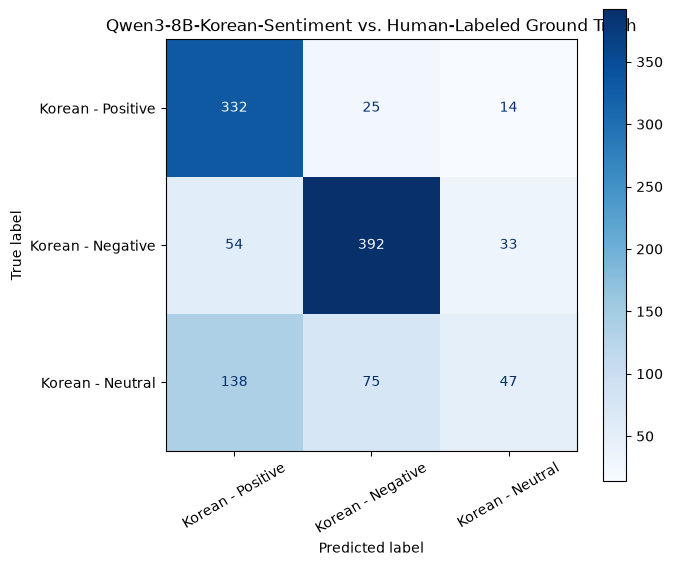

                   precision    recall  f1-score   support

Korean - Positive       0.63      0.89      0.74       371
Korean - Negative       0.80      0.81      0.81       481
 Korean - Neutral       0.50      0.18      0.26       262

        micro avg       0.69      0.69      0.69      1114
        macro avg       0.64      0.63      0.60      1114
     weighted avg       0.67      0.69      0.66      1114



In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

LABEL_ORDER = ['Positive', 'Negative', 'Neutral']
DISPLAY_LABELS = ['Korean - Positive', 'Korean - Negative', 'Korean - Neutral']

y_true = eval_df['Sentiment']
y_pred = eval_df['Predicted_Sentiment']

cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DISPLAY_LABELS)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title('Qwen3-8B-Korean-Sentiment vs. Human-Labeled Ground Truth')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=LABEL_ORDER, target_names=DISPLAY_LABELS))

In [20]:
df_english = pd.read_csv(
    os.path.join(DATA_DIR, 'df_english_cleaned.csv'),
    engine='python',
    on_bad_lines='skip',
)
print(df_english.shape)

(1032225, 2)


In [13]:
import os
import pandas as pd

DATA_DIR = '/workspace'
TEST_DIR = os.path.join(DATA_DIR, 'Test')
TRAIN_DIR = os.path.join(DATA_DIR, 'Train')

LANGUAGE_TEST_FILES = {
    'english': 'df_english_test.csv',
    'tamil': 'df_tamil_test.csv',
    'hinglish': 'df_hinglish_test.csv',
    'korean': 'df_korean_test.csv',
}

LANGUAGE_TRAIN_FILES = {
    'english': 'df_english_train.csv',
    'tamil': 'df_tamil_train.csv',
    'hinglish': 'df_hinglish_train.csv',
    'korean': 'df_korean_train.csv',
}

test_dfs = []
for language, filename in LANGUAGE_TEST_FILES.items():
    path = os.path.join(TEST_DIR, filename)
    df = pd.read_csv(path, engine='python', on_bad_lines='skip')
    df['Language'] = language
    test_dfs.append(df)
    print(f"{language} (test): {df.shape[0]} rows")

df_all = pd.concat(test_dfs, ignore_index=True)
print("\nTotal combined test rows:", df_all.shape)
df_all.head()

english (test): 206445 rows
tamil (test): 2072 rows
hinglish (test): 638 rows
korean (test): 1114 rows

Total combined test rows: (210269, 3)


,CommentText,Sentiment,Language
0,Would you parden Lavoy Finicum name as he died...,Neutral,english
1,😂😂😂🤣🤣🤣,Neutral,english
2,at 35:39 shouldn't the time complexity be O(2)...,Negative,english
3,Great series>👌🫶,Positive,english
4,17:13 “Zotac 5090 Solid which is better than l...,Positive,english


In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_ID = "AmaanP314/youtube-xlm-roberta-base-sentiment-multilingual"

roberta_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
roberta_model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
roberta_model.to('cuda' if torch.cuda.is_available() else 'cpu')
roberta_model.eval()

ROBERTA_LABEL_MAPPING = {0: "Negative", 1: "Neutral", 2: "Positive"}

config.json:   0%|          | 0.00/972 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [16]:
from tqdm.auto import tqdm

@torch.no_grad()
def predict_sentiment_batch(comments, batch_size=64, max_length=128):
    device = roberta_model.device
    predictions = []

    for i in tqdm(range(0, len(comments), batch_size), desc=f"RoBERTa inference (max_length={max_length})"):
        batch = [str(c) for c in comments[i:i + batch_size]]
        inputs = roberta_tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        ).to(device)

        outputs = roberta_model(**inputs)
        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()
        predictions.extend(ROBERTA_LABEL_MAPPING[p] for p in batch_preds)

    return predictions

In [18]:
print(df_tune.columns.tolist())
print(df_tune.shape)

['CommentText', 'Language']
(600, 2)


In [19]:
TUNE_SAMPLE_SIZE = 150

tune_dfs = []
for language, filename in LANGUAGE_TRAIN_FILES.items():
    path = os.path.join(TRAIN_DIR, filename)
    df = pd.read_csv(path, engine='python', on_bad_lines='skip')
    df['Language'] = language

    print(f"{language} columns: {df.columns.tolist()}")  # sanity check

    per_class_n = TUNE_SAMPLE_SIZE // 3
    class_samples = []
    for sentiment_value in df['Sentiment'].unique():
        subset = df[df['Sentiment'] == sentiment_value]
        n = min(len(subset), per_class_n)
        class_samples.append(subset.sample(n=n, random_state=42))

    lang_sample = pd.concat(class_samples, ignore_index=True)
    tune_dfs.append(lang_sample)

df_tune = pd.concat(tune_dfs, ignore_index=True)
print("\nTuning sample size:", df_tune.shape)
print("Columns:", df_tune.columns.tolist())
df_tune.head()

english columns: ['CommentText', 'Sentiment', 'Language']
tamil columns: ['CommentText', 'Sentiment', 'Language']
hinglish columns: ['CommentText', 'Sentiment', 'Language']
korean columns: ['CommentText', 'Sentiment', 'Language']

Tuning sample size: (600, 3)
Columns: ['CommentText', 'Sentiment', 'Language']


,CommentText,Sentiment,Language
0,"Damn, he almost lost his life over something h...",Negative,english
1,So cheesy,Negative,english
2,"DEAR PUTIN, \nThe whole world is watching, so ...",Negative,english
3,This California governor doesn't understand.. ...,Negative,english
4,"Sorry, it's just wrong. Theft is never good!",Negative,english


In [21]:
from sklearn.metrics import f1_score

CANDIDATE_MAX_LENGTHS = [32, 64, 128, 256]
tuning_results = {}

for max_len in CANDIDATE_MAX_LENGTHS:
    preds = predict_sentiment_batch(df_tune['CommentText'].tolist(), batch_size=64, max_length=max_len)
    score = f1_score(df_tune['Sentiment'], preds, average='macro')
    tuning_results[max_len] = score
    print(f"max_length={max_len}: macro F1 = {score:.4f}")

BEST_MAX_LENGTH = max(tuning_results, key=tuning_results.get)
print(f"\nBest max_length: {BEST_MAX_LENGTH} (macro F1 = {tuning_results[BEST_MAX_LENGTH]:.4f})")

RoBERTa inference (max_length=32):   0%|          | 0/10 [00:00<?, ?it/s]

max_length=32: macro F1 = 0.6175


RoBERTa inference (max_length=64):   0%|          | 0/10 [00:00<?, ?it/s]

max_length=64: macro F1 = 0.6312


RoBERTa inference (max_length=128):   0%|          | 0/10 [00:00<?, ?it/s]

max_length=128: macro F1 = 0.6349


RoBERTa inference (max_length=256):   0%|          | 0/10 [00:00<?, ?it/s]

max_length=256: macro F1 = 0.6349

Best max_length: 128 (macro F1 = 0.6349)


In [22]:
df_all['Predicted_Sentiment'] = predict_sentiment_batch(
    df_all['CommentText'].tolist(),
    batch_size=64,
    max_length=BEST_MAX_LENGTH,
)

RESULTS_PATH = os.path.join(DATA_DIR, 'df_all_roberta_predictions_test.csv')
df_all.to_csv(RESULTS_PATH, index=False)
print(f"Saved predictions to {RESULTS_PATH}")
df_all.head()

RoBERTa inference (max_length=128):   0%|          | 0/3286 [00:00<?, ?it/s]

Saved predictions to /workspace/df_all_roberta_predictions_test.csv


,CommentText,Sentiment,Language,Predicted_Sentiment
0,Would you parden Lavoy Finicum name as he died...,Neutral,english,Neutral
1,😂😂😂🤣🤣🤣,Neutral,english,Positive
2,at 35:39 shouldn't the time complexity be O(2)...,Negative,english,Negative
3,Great series>👌🫶,Positive,english,Positive
4,17:13 “Zotac 5090 Solid which is better than l...,Positive,english,Positive


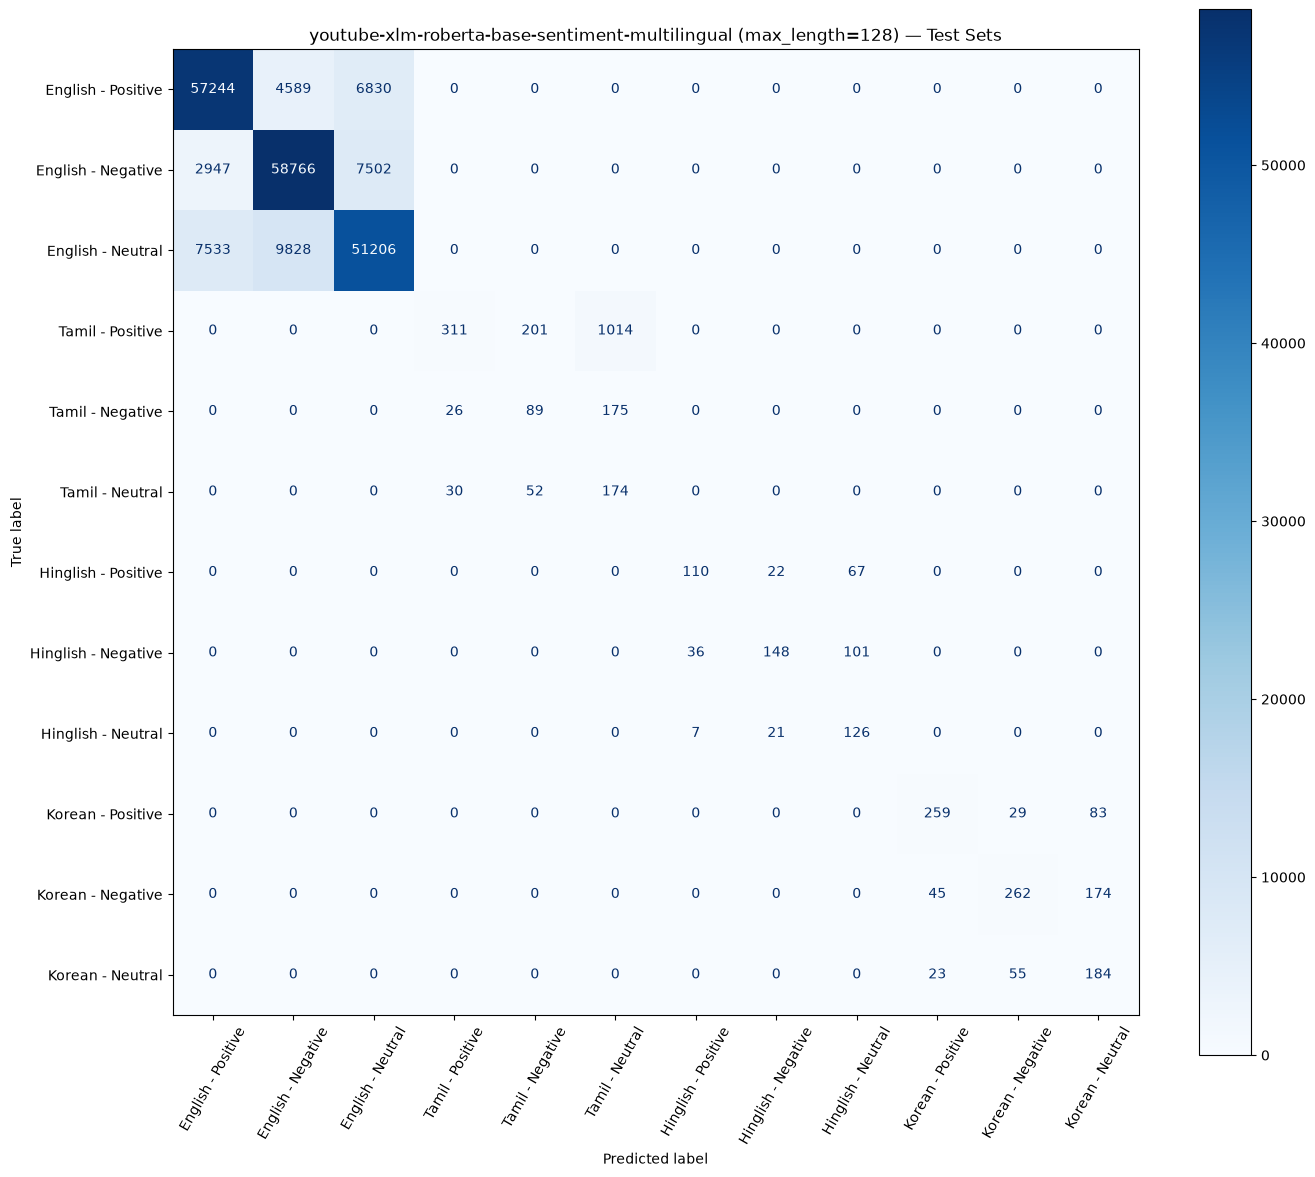

                     precision    recall  f1-score   support

 English - Positive       0.85      0.83      0.84     68663
 English - Negative       0.80      0.85      0.83     69215
  English - Neutral       0.78      0.75      0.76     68567
   Tamil - Positive       0.85      0.20      0.33      1526
   Tamil - Negative       0.26      0.31      0.28       290
    Tamil - Neutral       0.13      0.68      0.21       256
Hinglish - Positive       0.72      0.55      0.62       199
Hinglish - Negative       0.77      0.52      0.62       285
 Hinglish - Neutral       0.43      0.82      0.56       154
  Korean - Positive       0.79      0.70      0.74       371
  Korean - Negative       0.76      0.54      0.63       481
   Korean - Neutral       0.42      0.70      0.52       262

           accuracy                           0.80    210269
          macro avg       0.63      0.62      0.58    210269
       weighted avg       0.81      0.80      0.80    210269



In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# normalize casing, same fix as before
df_all['Sentiment'] = df_all['Sentiment'].str.strip().str.capitalize()
df_all['Language'] = df_all['Language'].str.strip().str.capitalize()

df_all['True_Label'] = df_all['Language'] + ' - ' + df_all['Sentiment']
df_all['Predicted_Label'] = df_all['Language'] + ' - ' + df_all['Predicted_Sentiment']

LABEL_ORDER = [
    'English - Positive', 'English - Negative', 'English - Neutral',
    'Tamil - Positive', 'Tamil - Negative', 'Tamil - Neutral',
    'Hinglish - Positive', 'Hinglish - Negative', 'Hinglish - Neutral',
    'Korean - Positive', 'Korean - Negative', 'Korean - Neutral',
]

cm = confusion_matrix(df_all['True_Label'], df_all['Predicted_Label'], labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=60)
ax.set_title(f'youtube-xlm-roberta-base-sentiment-multilingual (max_length={BEST_MAX_LENGTH}) — Test Sets')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'confusion_matrix_test_sets.png'), dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(df_all['True_Label'], df_all['Predicted_Label'], labels=LABEL_ORDER))